# Contexte du projet


Une équipe médicale souhaite tester l’apport de l’intelligence artificielle dans **le diagnostic automatisé de la pneumonie à partir de radios thoraciques.** Elle a besoin d’un prototype fonctionnel (Proof of Concept) permettant de démontrer la faisabilité d’**un système de classification binaire d’images médicales**.

>Le problème posé consiste à réutiliser un modèle de vision par ordinateur **pré-entraîné (type CNN)** pour l’adapter au contexte médical, sans repartir d’un entraînement complet.

> Dans une logique de mise en production à moyen terme, il est également attendu de documenter et tracer les expérimentations réalisées. L’usage de **MLflow** est proposé pour initier cette démarche, en assurant le suivi des performances, la traçabilité des essais et la gestion des versions de modèles dans une perspective MLOps.

# Modalités d'évaluation
Évaluation individuelle à partir du livrable (notebook). 
Le barème porte sur 
- **la qualité de la démarche (pertinence des choix, rigueur des étapes, clarté des explications),** 
- **la bonne compréhension du transfert learning,**
- **et l’initiation à MLflow (usage basique)**.

# Livrables
Un **lien GitHub** contenant les travaux réalisés, notamment un notebook complet, structuré, lisible et commenté, incluant :
- Préparation et exploration du dataset
- Mise en place du modèle pré-entraîné et adaptation
- Entraînement, évaluation (matrice de confusion, courbes, métriques etc...)
- Suivi des expériences via MLflow
- Le dépôt du code sur GitHub avec les travaux réalisé (notebook) avec un README synthétique

# Critères de performance
- Le notebook couvre toutes **les étapes clés de la démarche** (pré-traitement, modélisation, évaluation)
- Les **choix techniques sont justifiés** avec clarté et cohérence
- Le **modèle est adapté** de manière correcte à la tâche de classification binaire
- L’**évaluation du modèle est rigoureuse** (métriques pertinentes, commentaires clairs)
- La première utilisation de **MLflow est fonctionnelle et comprise** (log simple de paramètres ou de métriques)
- Le **code est structuré, commenté, exécutable**
- *La performance du modèle n'est pas un critère de performances, seul compte la démarche, la compréhension et donc la clarté des notes dans le le notebook*

----

# 1. Chargement des bibliothèques nécessaires

 - Création manuelle d'un environnment virtuel `python -m venv .venv` et l'activer ` .\.venv\Scripts\Activate.ps1` (sous windows os)
 - Installer les bibliothèques `pip install -r requirements.txt` 
 - choisir le dossier .venv dans "Python: Select interpreter" (Command Palette)
 (venv contenant python 3.10 compatible avec tensorflow)
 - installer ipykernel pour executer

In [13]:
import os  # os pour manipuler des dossiers et fichiers
import numpy as np # np pour manipuler des vecteurs et matrices
import pandas as pd # pd pour traiter des dataframe et visualiser des figures
import seaborn as sns # pd pour visualiser des figures

import mlflow #  pour documenter et tracer les expérimentations réalisées.
import mlflow.tensorflow
# DL Lib
import tensorflow as tf 

from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import DenseNet121, ResNet50V2
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt  #  pour visualiser des figures
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import roc_curve,roc_auc_score,auc, confusion_matrix, classification_report,accuracy_score # pd pour évaluer le modèle
import cv2


# 2. Préparation et exploration du dataset

[[[ 24  24  24]
  [ 20  20  20]
  [ 19  19  19]
  [ 17  17  17]
  [ 17  17  17]
  [ 28  28  28]
  [ 56  56  56]
  [ 58  58  58]
  [ 64  64  64]
  [ 65  65  65]
  [ 72  72  72]
  [ 74  74  74]
  [ 80  80  80]
  [ 86  86  86]
  [ 90  90  90]
  [ 90  90  90]
  [ 92  92  92]
  [ 91  91  91]
  [ 99  99  99]
  [ 98  98  98]
  [100 100 100]
  [ 99  99  99]
  [102 102 102]
  [102 102 102]
  [107 107 107]
  [107 107 107]
  [110 110 110]
  [115 115 115]
  [111 111 111]
  [134 134 134]
  ...
  [ 84  84  84]
  [ 88  88  88]
  [ 88  88  88]
  [ 93  93  93]
  [ 91  91  91]
  [ 93  93  93]
  [ 98  98  98]
  [ 98  98  98]
  [ 98  98  98]
  [ 99  99  99]
  [100 100 100]
  [115 115 115]
  [147 147 147]
  [168 168 168]
  [155 155 155]
  [140 140 140]
  [138 138 138]
  [133 133 133]
  [133 133 133]
  [138 138 138]
  [152 152 152]
  [166 166 166]
  [138 138 138]
  [ 96  96  96]
  [ 96  96  96]
  [ 94  94  94]
  [ 95  95  95]
  [ 95  95  95]
  [ 94  94  94]
  [ 95  95  95]]

 [[ 22  22  22]
  [ 22  22  22]


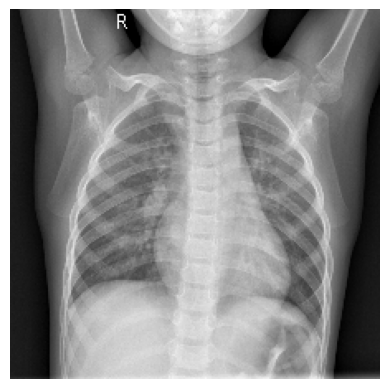

Shape (dimensions)    : (224, 224, 3)
Type des valeurs      : uint8


In [2]:
# On charge une image depuis le répertoire data/
img = cv2.imread("../data/train/NORMAL/IM-0115-0001.jpeg", cv2.IMREAD_GRAYSCALE)
# Convert to 3 channels
img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) # Now shape is (H, W, 3)
# Resize to model input size (e.g., 224x224)
resized_img = cv2.resize(img_rgb, (224, 224))
# Observer l'image sous forme de matrice
print(resized_img)

# Visualisation de l'image
plt.imshow(resized_img, cmap="gray")
plt.axis("off")
plt.show()

# Inspection des métadonnées de l'image
print(f"Shape (dimensions)    : {resized_img.shape}")
print(f"Type des valeurs      : {resized_img.dtype}")

## Chargement des données

In [3]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Create ImageDataGenerator instances & normalization
train_datagen = ImageDataGenerator(rescale=1./255)  
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_generator = train_datagen.flow_from_directory(
    '../data/train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'  # Converts grayscale to 3 channels automatically
)

val_generator = val_datagen.flow_from_directory(
    '../data/val',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'
)

test_generator = test_datagen.flow_from_directory(
    '../data/test',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False  # Usually better for evaluation
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## Vérification

In [4]:
def generator_to_numpy(generator):
    X = []
    y = []
    for i in range(len(generator)):
        X_batch, y_batch = generator[i]
        X.append(X_batch)
        y.append(y_batch)
    X = np.concatenate(X, axis=0)
    y = np.concatenate(y, axis=0)
    return X, y

# Convert generators to NumPy arrays
X_train, y_train = generator_to_numpy(train_generator)
X_val, y_val = generator_to_numpy(val_generator)
X_test, y_test = generator_to_numpy(test_generator)

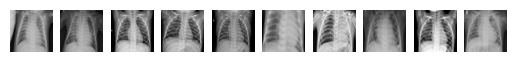

In [7]:
# Vérification des données préparées
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train[i], cmap="grey")
   
    plt.axis("off")

plt.show()

# 3. Modélisation & compilation

- Pour un transfer learning : choisir selon les performances le modèle de base pré-entrainé (VGG16, DenseNet121 ...) sur les données ImageNet
- Pour un ensemble learning : combiner plusieurs modèles ensemble

In [9]:
def build_model(base_model_class):
    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # freeze base

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.5)(x)
    x = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=x)
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_densenet = build_model(DenseNet121)
model_resnet = build_model(ResNet50V2)


---

# 4. Mlflow Auto-tracking 

In [10]:
mlflow.tensorflow.autolog()
mlflow.set_experiment("TransferLearning-Ensemble-XAI")

2025/05/25 22:26:06 INFO mlflow.tracking.fluent: Experiment with name 'TransferLearning-Ensemble-XAI' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///c:/Users/User/Desktop/DL_transfer_CNN_pneumonia/notebooks/mlruns/216018822317392868', creation_time=1748204766379, experiment_id='216018822317392868', last_update_time=1748204766379, lifecycle_stage='active', name='TransferLearning-Ensemble-XAI', tags={}>

## Fitting

In [11]:
with mlflow.start_run(run_name="run-ensemble"):
    model_densenet.fit(train_generator, validation_data=val_generator, epochs=5)
    model_resnet.fit(train_generator, validation_data=val_generator, epochs=5)

     # log the model
    mlflow.keras.log_model(model_densenet,"model_densenet")
    mlflow.keras.log_model(model_resnet,"model_resnet")
    

2025/05/25 22:38:43 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/05/25 22:38:43 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
c:\Users\User\Desktop\DL_transfer_CNN_pneumonia\.venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6185 - loss: 0.7900

163/163 ━━━━━━━━━━━━━━━━━━━━ 696s 4s/step - accuracy: 0.6187 - loss: 0.7896 - val_accuracy: 0.5000 - val_loss: 0.8839
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7038 - loss: 0.6372

163/163 ━━━━━━━━━━━━━━━━━━━━ 676s 4s/step - accuracy: 0.7039 - loss: 0.6370 - val_accuracy: 0.5000 - val_loss: 0.7864
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7508 - loss: 0.5280

163/163 ━━━━━━━━━━━━━━━━━━━━ 535s 3s/step - accuracy: 0.7509 - loss: 0.5279 - val_accuracy: 0.5000 - val_loss: 0.7190
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7795 - loss: 0.4757

...

163/163 ━━━━━━━━━━━━━━━━━━━━ 466s 3s/step - accuracy: 0.7991 - loss: 0.4215 - val_accuracy: 0.6875 - val_loss: 0.5232
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8689 - loss: 0.3031

163/163 ━━━━━━━━━━━━━━━━━━━━ 478s 3s/step - accuracy: 0.8689 - loss: 0.3030 - val_accuracy: 0.6875 - val_loss: 0.4817
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8919 - loss: 0.2603

163/163 ━━━━━━━━━━━━━━━━━━━━ 464s 3s/step - accuracy: 0.8919 - loss: 0.2603 - val_accuracy: 0.7500 - val_loss: 0.4409
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9101 - loss: 0.2250

163/163 ━━━━━━━━━━━━━━━━━━━━ 454s 3s/step - accuracy: 0.9101 - loss: 0.2250 - val_accuracy: 0.8125 - val_loss: 0.4131


2025/05/26 00:07:37 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: '>=' not supported between instances of 'slice' and 'int'
2025/05/26 00:07:37 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/26 00:07:51 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/05/26 00:07:51 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/05/26 00:08:13 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/05/26 00:08:13 WARNING mlflow.keras.save

In [16]:
# Predict on test data
vgg_preds = model_densenet.predict(test_generator)
resnet_preds = model_resnet.predict(test_generator)

# Average predictions
ensemble_preds = (vgg_preds + resnet_preds) / 2
ensemble_preds_binary = (ensemble_preds > 0.5).astype(int)

y_true = test_generator.classes
print("\nClassification Report:")
print(classification_report(y_true, ensemble_preds_binary))

# Compute ensemble accuracy
ensemble_accuracy = accuracy_score(y_true, ensemble_preds_binary)
print(f"Ensemble Accuracy: {ensemble_accuracy:.4f}")

print("Confusion Matrix:")
print(confusion_matrix(y_true, ensemble_preds_binary))


KeyboardInterrupt: 

In [15]:
ensemble_accuracy = accuracy_score(y_true, ensemble_preds_binary)
ensemble_accuracy

0.7548076923076923

# 6. Comparaison des modèles 

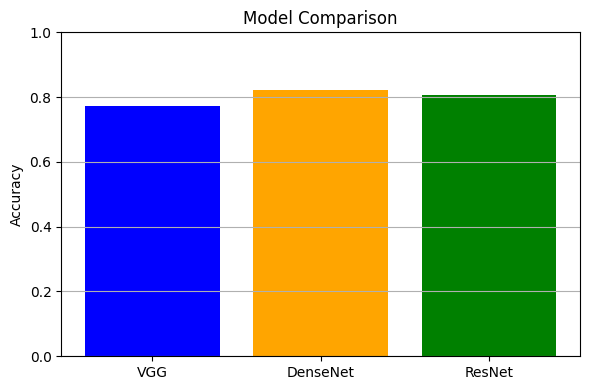

In [ ]:
models = [model_vgg,model_densenet,model_resnet]
test_accuracies =[]
for model in models:
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    test_accuracies.append(test_acc)
labels = ["VGG", "DenseNet", "ResNet"]
plt.figure(figsize=(6, 4))
plt.bar(labels, test_accuracies, color=['blue', 'orange', 'green'])
plt.ylim(0, 1)  # Accuracy ranges from 0 to 1
plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("../figures/model_comparison.png")
plt.show()
    

==> Le modèle basé sur Densnet est le meilleur en terme d'accuracy.

---

## Mlflow ui
Pour visualiser les expérimentations suivies 
- changer de répertoire:
cd  notebooks/
- entrer la commande
`mlflow ui `
- ouvrir http://localhost:5000